<a href="https://colab.research.google.com/github/AtharvaTakawale/Next-Word-Predictor/blob/main/House_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("housing.csv")

In [3]:
data


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.dropna(inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [7]:
from sklearn.model_selection import train_test_split

X = data.drop('median_house_value', axis=1)
y = data['median_house_value']

In [8]:
X

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,NEAR BAY
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,INLAND


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [10]:
train_data = X_train.join(y_train)

In [11]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
20580,-121.77,38.76,32.0,1950.0,385.0,1145.0,363.0,2.8365,INLAND,87900.0
14662,-117.13,32.80,33.0,2731.0,456.0,1263.0,445.0,4.5568,NEAR OCEAN,175300.0
12365,-116.47,33.81,7.0,10105.0,2481.0,6274.0,2095.0,2.4497,INLAND,90900.0
790,-122.08,37.64,36.0,1340.0,245.0,789.0,248.0,3.8000,NEAR BAY,172000.0
3305,-122.65,38.96,27.0,2143.0,580.0,898.0,367.0,1.6769,INLAND,63200.0
...,...,...,...,...,...,...,...,...,...,...
8361,-118.33,33.96,42.0,1686.0,361.0,737.0,319.0,2.3000,<1H OCEAN,189200.0
12633,-121.49,38.49,26.0,4629.0,832.0,2902.0,816.0,2.7350,INLAND,74600.0
5800,-118.24,34.15,7.0,2063.0,670.0,1892.0,643.0,1.7301,<1H OCEAN,202300.0
2140,-119.75,36.77,32.0,1962.0,399.0,1005.0,392.0,2.6726,INLAND,70400.0


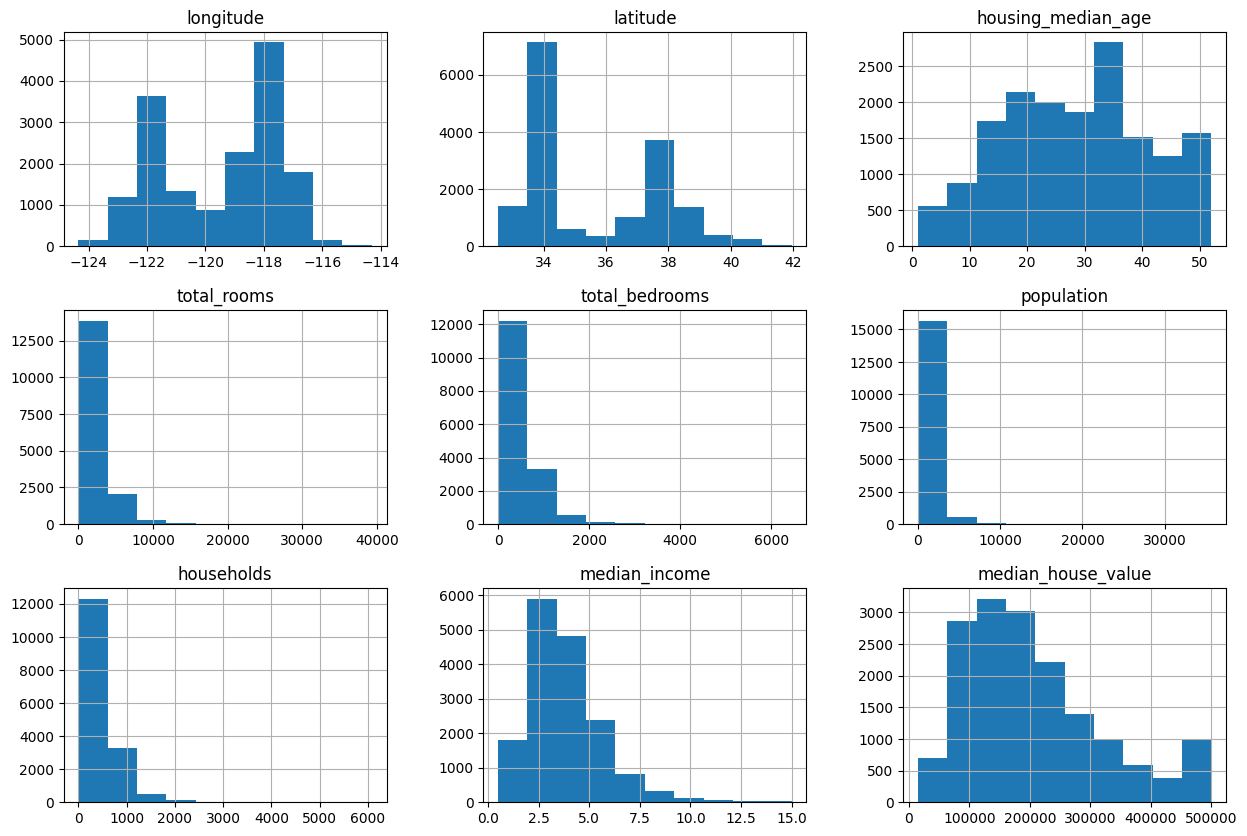

In [12]:
train_data.hist(figsize=(15, 10))
plt.show()

<Axes: >

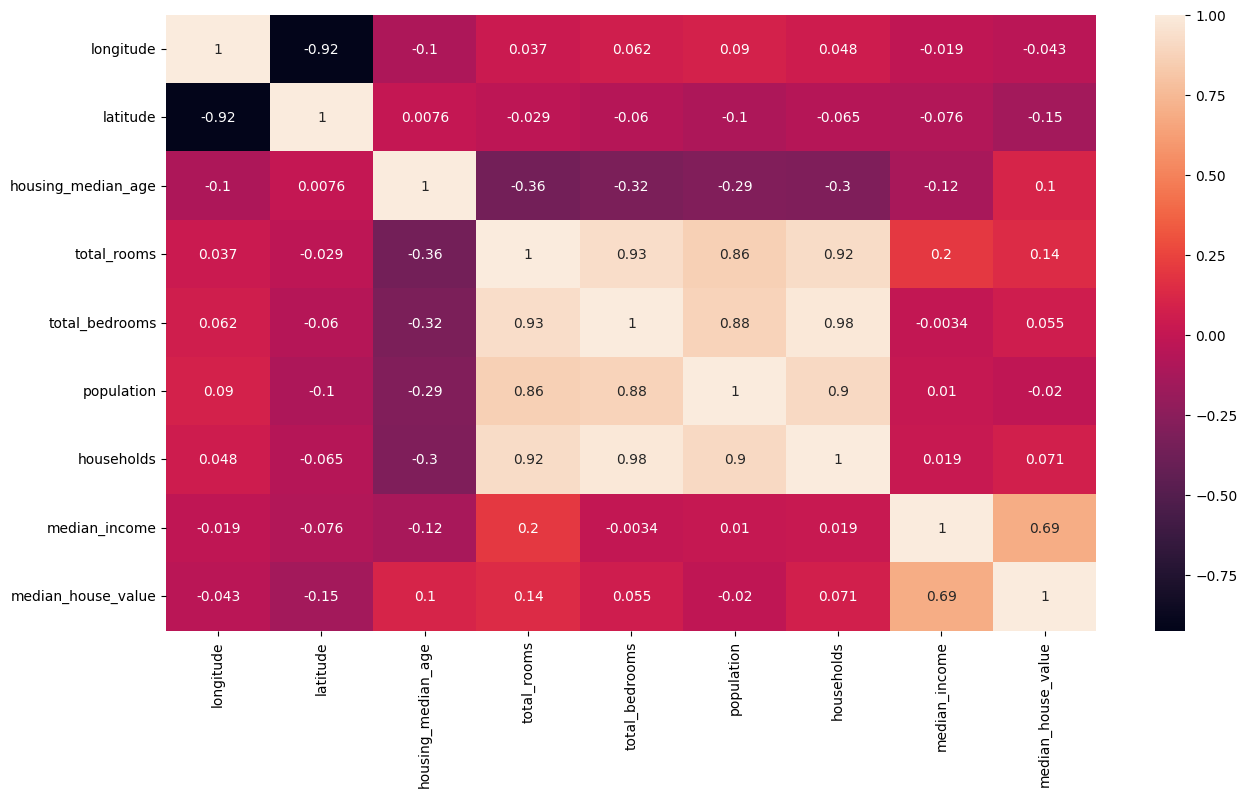

In [13]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

In [14]:
train_data['total_rooms'] = np.log(train_data['total_rooms'] + 1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms'] + 1)
train_data['population'] = np.log(train_data['population'] + 1)
train_data['households'] = np.log(train_data['households'] + 1)

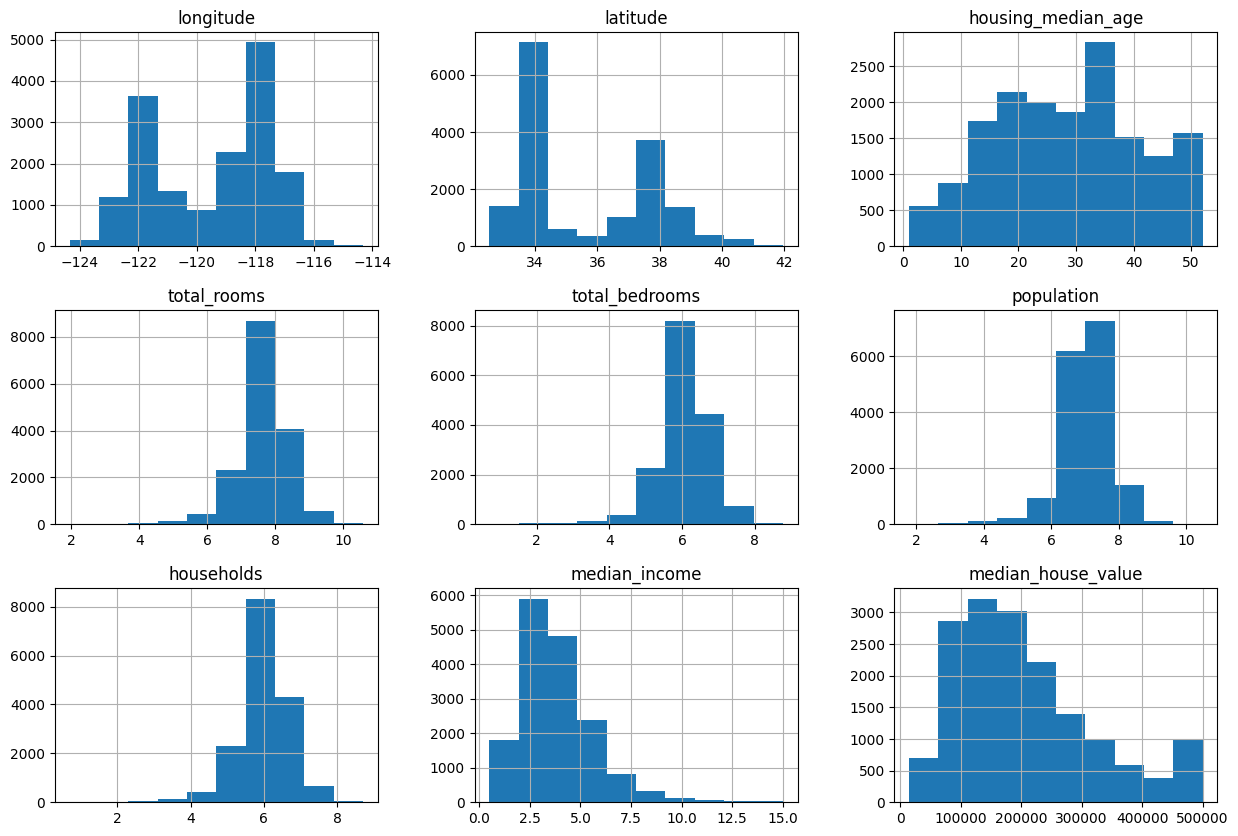

In [15]:
train_data.hist(figsize=(15, 10))
plt.show()

In [16]:
train_data.join(pd.get_dummies(data['ocean_proximity'], dtype=int)).drop(['ocean_proximity'], axis=1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
20580,-121.77,38.76,32.0,7.576097,5.955837,7.044033,5.897154,2.8365,87900.0,0,1,0,0,0
14662,-117.13,32.80,33.0,7.912789,6.124683,7.142037,6.100319,4.5568,175300.0,0,0,0,0,1
12365,-116.47,33.81,7.0,9.220885,7.816820,8.744329,7.647786,2.4497,90900.0,0,1,0,0,0
790,-122.08,37.64,36.0,7.201171,5.505332,6.672033,5.517453,3.8000,172000.0,0,0,0,1,0
3305,-122.65,38.96,27.0,7.670429,6.364751,6.801283,5.908083,1.6769,63200.0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8361,-118.33,33.96,42.0,7.430707,5.891644,6.603944,5.768321,2.3000,189200.0,1,0,0,0,0
12633,-121.49,38.49,26.0,8.440312,6.725034,7.973500,6.705639,2.7350,74600.0,0,1,0,0,0
5800,-118.24,34.15,7.0,7.632401,6.508769,7.545918,6.467699,1.7301,202300.0,1,0,0,0,0
2140,-119.75,36.77,32.0,7.582229,5.991465,6.913737,5.973810,2.6726,70400.0,0,1,0,0,0


<Axes: >

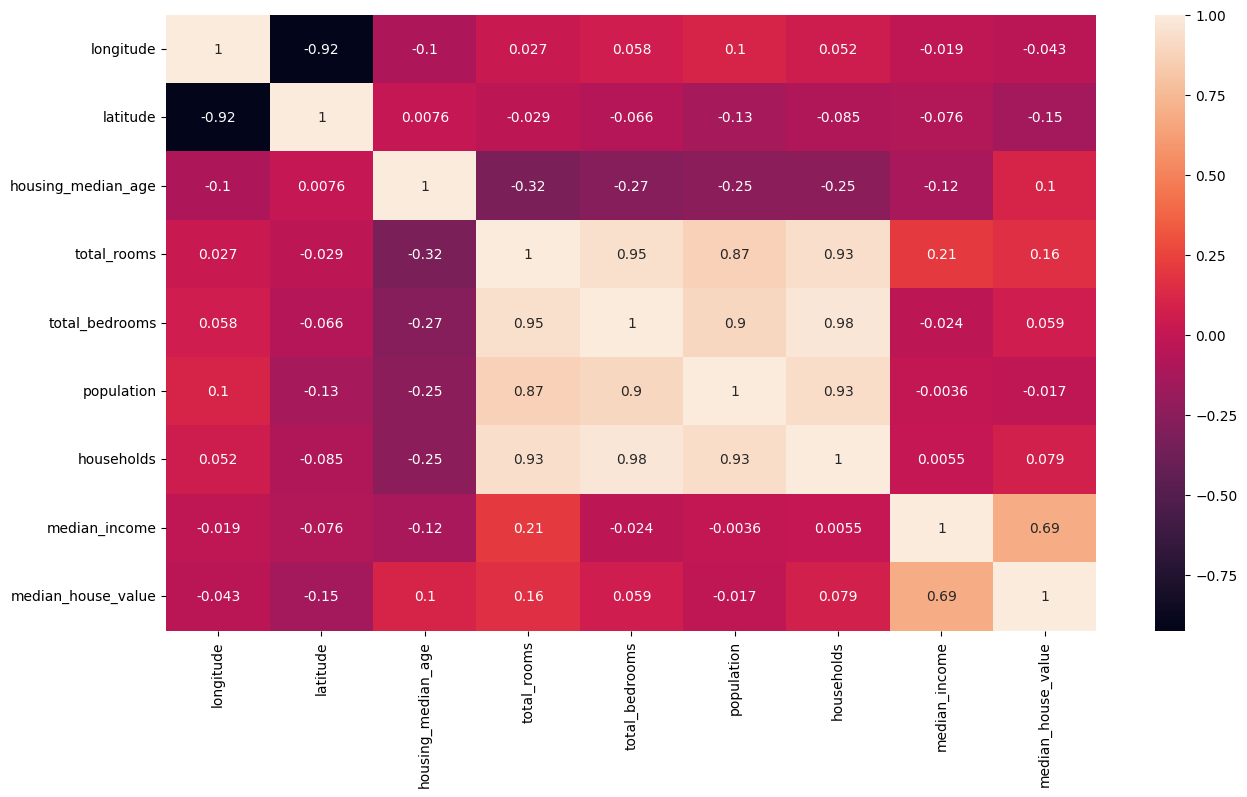

In [17]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

In [18]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
20580,-121.77,38.76,32.0,7.576097,5.955837,7.044033,5.897154,2.8365,INLAND,87900.0
14662,-117.13,32.80,33.0,7.912789,6.124683,7.142037,6.100319,4.5568,NEAR OCEAN,175300.0
12365,-116.47,33.81,7.0,9.220885,7.816820,8.744329,7.647786,2.4497,INLAND,90900.0
790,-122.08,37.64,36.0,7.201171,5.505332,6.672033,5.517453,3.8000,NEAR BAY,172000.0
3305,-122.65,38.96,27.0,7.670429,6.364751,6.801283,5.908083,1.6769,INLAND,63200.0
...,...,...,...,...,...,...,...,...,...,...
8361,-118.33,33.96,42.0,7.430707,5.891644,6.603944,5.768321,2.3000,<1H OCEAN,189200.0
12633,-121.49,38.49,26.0,8.440312,6.725034,7.973500,6.705639,2.7350,INLAND,74600.0
5800,-118.24,34.15,7.0,7.632401,6.508769,7.545918,6.467699,1.7301,<1H OCEAN,202300.0
2140,-119.75,36.77,32.0,7.582229,5.991465,6.913737,5.973810,2.6726,INLAND,70400.0


<Axes: xlabel='longitude', ylabel='latitude'>

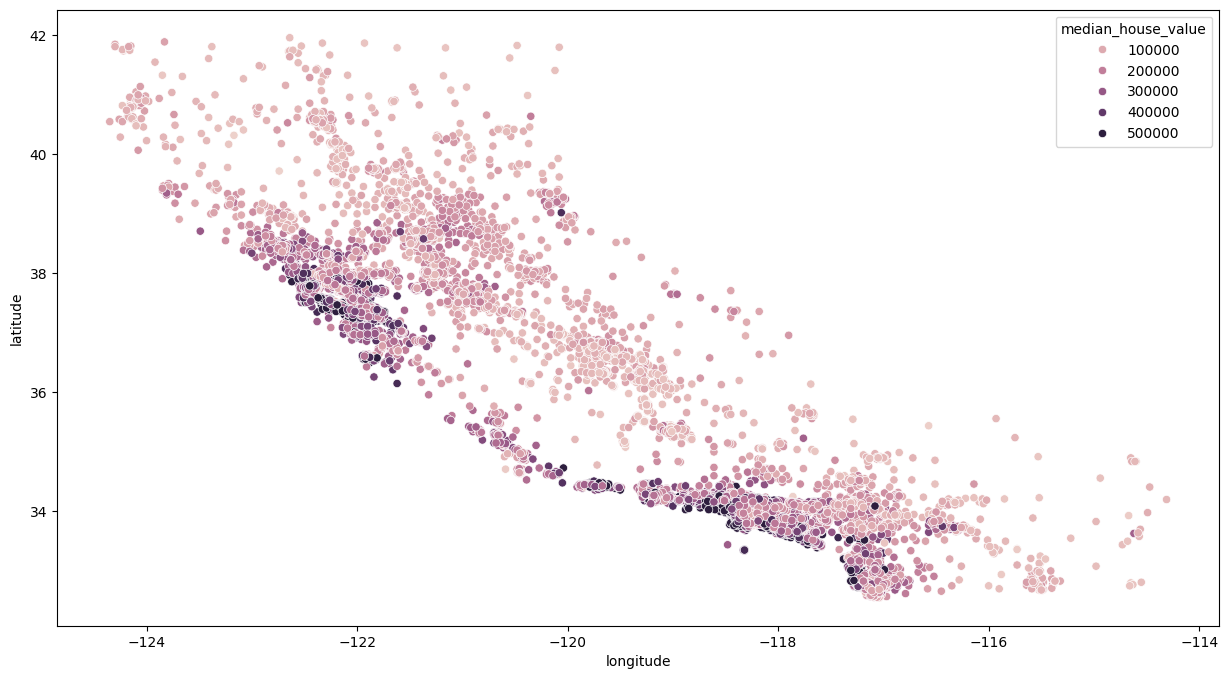

In [19]:
plt.figure(figsize=(15,8))
sns.scatterplot(data=train_data, x='longitude', y='latitude', hue='median_house_value')

In [20]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms']
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households']

<Axes: >

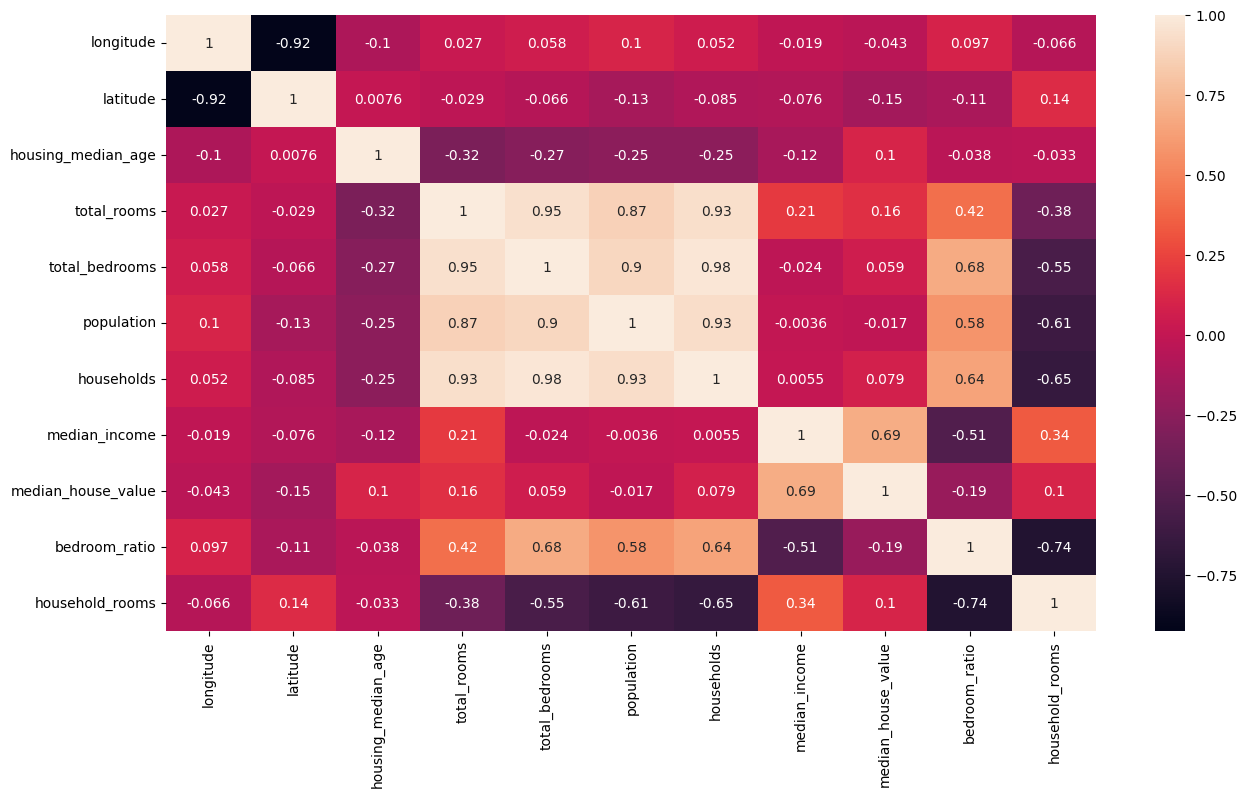

In [21]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True), annot=True)

In [22]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_encoded = pd.get_dummies(train_data.drop('median_house_value', axis=1), columns=['ocean_proximity'], drop_first=True)
y_train = train_data['median_house_value']
X_train_encoded_s = scaler.fit_transform(X_train_encoded)

reg = LinearRegression()
reg.fit(X_train_encoded_s, y_train)

LinearRegression()

In [23]:
test_data = X_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms'] + 1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms'] + 1)
test_data['population'] = np.log(test_data['population'] + 1)
test_data['households'] = np.log(test_data['households'] + 1)

# The previous line incorrectly encoded and dropped 'ocean_proximity' prematurely.
# This step should be done when preparing X_test_encoded to ensure consistency with X_train_encoded.

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms']
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

In [24]:
X_test_processed = test_data.drop('median_house_value', axis=1)
X_test_encoded = pd.get_dummies(X_test_processed, columns=['ocean_proximity'], drop_first=True)

# Get columns from the training set
train_cols = X_train_encoded.columns

# Add missing columns to X_test_encoded and set them to 0
missing_in_test = set(train_cols) - set(X_test_encoded.columns)
for c in missing_in_test:
    X_test_encoded[c] = 0

# Ensure the order of columns is the same as in X_train_encoded
X_test_encoded = X_test_encoded[train_cols]

y_test = test_data['median_house_value']

In [25]:
X_test_encoded_s = scaler.transform(X_test_encoded)

In [26]:
reg.score(X_test_encoded_s, y_test)

0.6815973260405699

In [27]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
forest.fit(X_train_encoded_s, y_train)

RandomForestRegressor()

In [28]:
forest.score(X_test_encoded_s, y_test)

0.8159979129463075

In [29]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    "n_estimators": [100, 200, 300],
    "min_samples_split": [2, 4],
    "max_depth": [None, 4, 8],
}

grid_search = GridSearchCV(forest, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True)

grid_search.fit(X_train_encoded_s, y_train)

GridSearchCV(cv=5, estimator=RandomForestRegressor(),
             param_grid={'max_depth': [None, 4, 8], 'min_samples_split': [2, 4],
                         'n_estimators': [100, 200, 300]},
             return_train_score=True, scoring='neg_mean_squared_error')

In [30]:
grid_search.best_estimator_

RandomForestRegressor(n_estimators=300)

In [31]:
best_forest = grid_search.best_estimator_

In [32]:
best_forest.score(X_test_encoded_s, y_test)

0.8185900781458247